# Simple Demonstration of Topk

This notebook demonstrates how to use the code for Topk, a method described in detail in this [preprint](https://arxiv.org/abs/2408.12332).  
Essentially, we train a random forest (RF) and leverage its smoother-properties as described for example in [Meinshausen (2006)](https://www.jmlr.org/papers/volume7/meinshausen06a/meinshausen06a.pdf), where a prediction is represented as a weighted sum over training observations.  
The Topk method discards most of the (presumably noisy) weights, resulting in a (very) sparse sum of only few, "$k$", observations.  
This helps to interpret and communicate a RF's prediction and can increase predictive performance.  
  
This notebook shows how you how to use Topk to 
1. generate mean and probabilistic predictions
2. replicate the results of our paper yourself

The code (as this notebook) can be found [here](https://github.com/kosnil/simplify_rf_dist).

## Imports

Import all needed packages, and set a seed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

SEED = 7531
np.random.seed(SEED)

from utils.plotting_helpers import *
from utils.score_utils import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from RF import RandomForestWeight


## Data

Of course, we need some data. So let's use what we used in the paper, openML and load the well-known data set 'California Housing'.  
[openML](https://www.openml.org/) is a platform that provides an easily accessible API to download data sets.  
For the sake of completeness, we provide code to load all tested data sets.

In [2]:
# Get all datasets from OpenML that are used in the paper
import openml
all_ids = list(range(44132, 44149)) + [45032, 45034]
all_ids.remove(44135)

all_ds = [openml.datasets.get_dataset(pid) for pid in all_ids]
ds_names = [ds.name for ds in all_ds]

# Exemplary, we will use the well-known dataset "California housing" for the rest of the notebook which is called "houses" above.
# Load the dataset
ds = all_ds[ds_names.index('houses')]  #5:california housing
print('dataset:', ds.name, '--- target:', ds.default_target_attribute)

X, y, _, _ = ds.get_data(target=ds.default_target_attribute, dataset_format='dataframe')

# Split the dataset into train and test sets
TEST_SIZE = 0.3
df_train, df_test, y_train, y_test = train_test_split(X, y.values, test_size=TEST_SIZE, random_state=SEED)

# Convert the dataframes to numpy arrays
X_train = df_train.values
X_test = df_test.values
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

print(f'Train on {X_train.shape[0]} samples, test on {X_test.shape[0]} samples')

dataset: houses --- target: medianhousevalue
Train on 14448 samples, test on 6192 samples


## Topk Model Training

Define hyperparameters and the model.  
Topk does not alter the training process compared to a standard RF in any way. Even though we only tested Topk on the standard RF and QRF, it can also be applied to any other RF-like model.

$k$ is the most important parameter here: the smaller it is, the easier the communication and interpretation of the forecast but performance suffers (in most cases).  
The larger the value $k$, performance increases but interpretation suffers. If chosen very large, converges to the performance of the original, "full" RF.

In [ ]:
# define hyperparameters for Random Forest
N_TREES = 1000
TOP_K_MAX = 100 # loop through each k from 1 to TOP_K_MAX. This should take about a minute for the defined parameters
NO_PROCESSES = 4 # number of processes to use for parallelization

hyperparams = dict(
    n_estimators=N_TREES,
    random_state=SEED,
    n_jobs=-1,
    max_features='sqrt',
    min_samples_split=5,
)

# Create a Topk RF. 
rf = RandomForestWeight(hyperparams=hyperparams, name='rf_' + ds.name)
rf.fit(X_train, y_train)

## Experimental loop

The function `topk_looper` takes care of looping over each k in parallel and recording various things for you automatically.  

We track the following out-of-sample variables:

**Mean Prediction**
- $R^2$
- Correlation between prediction and outcome
- Covariance between prediction and outcome
- Squared error
- Bias of prediction
- Variance of prediction
- Predictions

**Median & Probabilistic Prediction**
- Absolute error
- CPRS

**Other**
- Weight sum of the top k weights (before re-normalizing)

In [4]:
results_ds = topk_looper(
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    rf=rf,
    k_max=TOP_K_MAX,
    num_processes=NO_PROCESSES,
    verbose=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Done Training. Calculating Metrics
Time taken: 61.95s


Let's take a look at the results. `results_ds` holds the SE, AE and CRPS for each k and test case, so let's mean over the test cases.

In [5]:
results_ds['mse'] = results_ds['se'].mean(axis=1)
results_ds['mae'] = results_ds['ae'].mean(axis=1)
results_ds['mcrps'] = results_ds['crps'].mean(axis=1)

# Same for the topk weight sum. Add a 1 to the end of the array to get the topk weight sum for k=n
results_ds['mean_topk_sums'] = results_ds['topk_sums'].mean(axis=1)
results_ds['mean_topk_sums'] = np.append(results_ds['mean_topk_sums'], 1)

r2_full = results_ds['r2'][-1]
corr_full = results_ds['corr'][-1]
mse_full = results_ds['mse'][-1]
mae_full = results_ds['mae'][-1]
mcrps_full = results_ds['mcrps'][-1]

# Convert the results to a pandas dataframe
# and set the index to the k values
# The last entry is the full RF, so we need to remove it
df_res = pd.DataFrame({key: results_ds[key][:-1] for key in ('r2', 'corr', 'mse', 'mae', 'mcrps', 'mean_topk_sums')})
df_res.set_index(np.arange(1, TOP_K_MAX + 1), inplace=True)

df_res["rel_mse"] = df_res["mse"] / mse_full
df_res["rel_mae"] = df_res["mae"] / mae_full
df_res["rel_mcrps"] = df_res["mcrps"] / mcrps_full


We could for example now find the best performing value of k for each loss:

In [6]:
df_res[['rel_mse', 'rel_mae', 'rel_mcrps']].idxmin() + 1

rel_mse      24
rel_mae      28
rel_mcrps    39
dtype: int64

Or plot the results:

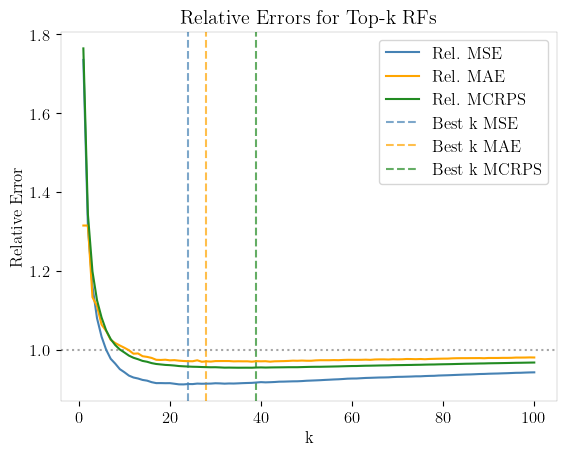

In [7]:
plt.plot(df_res['rel_mse'], color='steelblue', label='Rel. MSE')
plt.plot(df_res['rel_mae'], color='orange', label='Rel. MAE')
plt.plot(df_res['rel_mcrps'], color='forestgreen', label='Rel. MCRPS')
plt.xlabel('k')
plt.ylabel('Relative Error')
plt.title('Relative Errors for Top-k RFs')
plt.axvline(x=df_res['rel_mse'].idxmin() + 1, color='steelblue', linestyle='--', alpha=.7, zorder=-1, label='Best k MSE')
plt.axvline(x=df_res['rel_mae'].idxmin() + 1, color='orange', linestyle='--', alpha=.7, zorder=-1, label='Best k MAE')
plt.axvline(x=df_res['rel_mcrps'].idxmin() + 1, color='forestgreen', linestyle='--', alpha=.7, zorder=-1, label='Best k MCRPS')
plt.axhline(y=1, color='grey', linestyle=':', alpha=.7, zorder=-1)
plt.legend()

The plot shows what we described earlier: For small values of $k$, performance decreases quite drastically.  
Performance is best for $k$ of around 20-40, depending on the intended forecast (mean, median, distribution).  
For a larger growing $k$, the Topk performance converges to the full RF's performance.

## Predictions with Topk

The RF-class offers multiple ways to issue mean forecasts.  
For the full RFs mean forecast, you have two options:
1. Use `rf.predict()`, which simply uses sklearn's RF predict()-method
2. Use `rf.weight_predict()` that extracts weights from the RF (and returns those if needed)

In [8]:
y_hat1 = rf.predict(X_test)
y_hat2, w_all = rf.weight_predict(X_test, return_weights=True)

assert np.allclose(y_hat1, y_hat2), "Predictions are not equal!"

For a Topk prediction, simply pass a value for top_k in the function `weight_predict`:

In [9]:
k = 5
y_hat_k, w_k = rf.weight_predict(X_test, top_k=k, return_weights=True)

Since this already gives us the weights, we can issue our predicted scenarios as well.  
Let's take a look at the first test point.

In [10]:
w_1 = w_k[0]
scenarios = np.where(w_1 > 0)[0]

df_train['weight'] = 0.
df_train['weight'].iloc[scenarios] = w_1[scenarios]

df_train.iloc[scenarios].sort_values(by='weight', ascending=False, inplace=False)

/tmp/ipykernel_2492/996349974.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['weight'].iloc[scenarios] = w_1[scenarios]


,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude,weight
3574,3.0926,6,3218.0,949.0,2295.0,876.0,34.24,-118.52,0.376277
5778,3.0000,14,2981.0,894.0,1941.0,863.0,34.15,-118.26,0.253067
5900,3.1823,12,3188.0,931.0,2118.0,850.0,34.17,-118.31,0.152629
3959,3.2297,10,2869.0,941.0,2162.0,829.0,34.20,-118.60,0.111657
3841,2.8910,11,2891.0,951.0,2166.0,768.0,34.19,-118.44,0.106371


For quantile predictions, we can use the function `quantile_predict`.  
If you already computed weights (doesn't matter if they are the full RF's weights or Topk weights)

In [11]:
q_95_hat = rf.quantile_predict(q=.95, X_test=X_test)

You can pass them to the function so that you don't have to compute them again.

In [12]:
q_95_hat = rf.quantile_predict(q=.95, w_all=w_all)

You can also pass multiple quantile levels:

In [19]:
qs_hat = rf.quantile_predict(q=[0.05*i for i in range(1,20)], w_all=w_all)
qs_hat.shape

(6192, 19)

Also possible is to plot the full CDF for a given sample. We already have all necessary information:

Text(0.5, 1.0, 'Forecast distribution for first test sample')

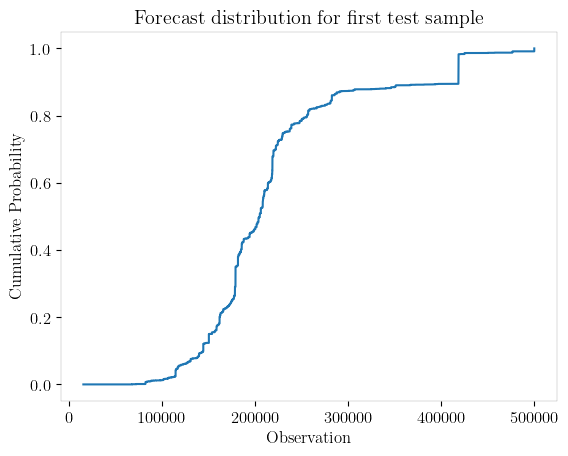

In [23]:
target_sort = np.argsort(y_train)
y_train_sorted = y_train[target_sort]

w_sorted = w_all[:, target_sort]
# Since the target is log-transformed, it's useful to bring it back to the original scale such that the CDF is easier to interpret

plt.plot(np.exp(y_train_sorted), np.cumsum(w_sorted[0, :]))
plt.xlabel('Observation')
plt.ylabel('Cumulative Probability')
plt.title('Forecast distribution for first test sample')